In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, sbi, torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sbi.inference import SNPE, SNLE
from sbi.utils.get_nn_models import posterior_nn, likelihood_nn
from sbi.inference import likelihood_estimator_based_potential, MCMCPosterior
from sbi import utils as utils
from sbi import analysis as analysis 

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files, logger

24-01-17 02:15:33   imports.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
# get number of GPUs available, should be 1
print(torch.cuda.device_count())
# device = "cuda"
device = "cpu"

LOGGER = logger.get_logger(os.getcwd())

1


# load network predictions

### v6

In [4]:
# lensing
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# MSE loss
# model_dir = "mse/2024-01-08_03-05-03_resnet_vanilla"

# likelihood loss
# model_dir = "mse/2024-01-05_22-04-15_resnet_vanilla"
# model_dir = "mse/2024-01-08_06-13-14_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [5]:
# # clustering
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/clustering_only"

# # # delta loss

# # # MSE loss
# # model_dir =

# # # likelihood loss
# model_dir = "mse/2024-01-08_10-05-55_resnet_vanilla"

# n_steps = 40000
# params = ["Om", "s8", "w0", "bg", "n_bg"]

### general

In [6]:
file_dict = input_output.load_preds(base_dir, model_dir, n_steps)

fidu_preds = file_dict["fiducial/vali/pred"]
grid_preds = file_dict["grid/pred"]
grid_cosmos = file_dict["grid/cosmo"]

# only relevant for the likelihood loss
n_params = len(params)
fidu_preds = fidu_preds[...,:n_params]
grid_preds = grid_preds[...,:n_params]

# combine the example and cosmology axes
grid_preds = np.concatenate(grid_preds, axis=0)
grid_cosmos = np.repeat(grid_cosmos, grid_preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(f"\nShapes after concatenation:")
print(f"grid_preds  = {grid_preds.shape}")
print(f"grid_cosmos = {grid_cosmos.shape}")

24-01-17 02:15:34 input_output INF   Array shapes:
 
24-01-17 02:15:34 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-17 02:15:34 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-17 02:15:34 input_output INF   grid/cosmo         = (2500, 5) 
24-01-17 02:15:34 input_output INF   grid/i_sobol       = (2500,) 
24-01-17 02:15:34 input_output INF   grid/i_example     = (2500, 48) 
24-01-17 02:15:34 input_output INF   grid/i_noise       = (2500, 48) 

Shapes after concatenation:
grid_preds  = (120000, 5)
grid_cosmos = (120000, 5)


In [7]:
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_sbi"

### observation

In [8]:
# i_obs = 0

i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
print(f"The example index closest to the median is {i_obs}")

obs_pred = fidu_preds[i_obs]
obs_pred = torch.tensor(obs_pred, dtype=torch.float32, device=device)

The example index closest to the median is 1


# SBI

### uniform prior 

In [9]:
# TODO adapt Aadi's prior
prior_intervals = parameters.get_prior_intervals(params)
prior_intervals_low = torch.tensor(prior_intervals[:,0], dtype=torch.float32)
prior_intervals_high = torch.tensor(prior_intervals[:,1], dtype=torch.float32)
prior = utils.BoxUniform(low=prior_intervals_low, high=prior_intervals_high, device=device)

In [10]:
theta = torch.tensor(grid_cosmos, dtype=torch.float32, device=device)
x = torch.tensor(grid_preds, dtype=torch.float32, device=device)

# SNPE

In [11]:
# # from https://sbi-dev.github.io/sbi/reference/#sbi.utils.get_nn_models.posterior_nn

# # Masked Autoregressive Flow (MAF)
# density_estimator = posterior_nn(
#     model="maf", 
#     hidden_features=128, 
#     num_transforms=5,
# )

# # # Neural Spline Flow (NSF)
# # density_estimator = posterior_nn(
# #     model="nsf", 
# #     hidden_features=256, 
# #     num_transforms=5,
# #     num_bins=10,
# # )

# # # Mixture Density Network (MDN)
# # density_estimator = posterior_nn(
# #     model="mdn", 
# #     hidden_features=256, 
# #     num_components=10,
# # )

In [12]:
# # set up inference
# inference = SNPE(
#     prior=prior,
#     density_estimator=density_estimator,
#     show_progress_bars=True, 
#     device=device,
# )
# inference = inference.append_simulations(theta, x)

# # training
# LOGGER.timer.start("training")
# density_estimator = inference.train(
#     training_batch_size=1000,
#     learning_rate=0.01,
#     clip_max_norm=10.0,
#     stop_after_epochs=20,
#     max_num_epochs=1000, 
#     # misc
#     validation_fraction=0.1,
#     show_train_summary=False
# )
# print(f"\nDone with training after {LOGGER.timer.elapsed('training')}")

In [13]:
# fig, ax = plt.subplots(figsize=(12,6))

# ax.plot(-np.array(inference._summary["training_log_probs"]))
# ax.plot(-np.array(inference._summary["validation_log_probs"]))

# ax.set(xlabel="epochs", ylabel="loss")
# ax.grid(True)

In [14]:
# posterior = inference.build_posterior(density_estimator)
# print(posterior)

# posterior_samples = posterior.sample(
#     (int(1e6),), 
#     x=obs_pred, 
#     show_progress_bars=True
# ) 
# posterior_samples = posterior_samples.cpu().numpy()

### plot

In [15]:
# plotting.plot_chains(
#     posterior_samples, 
#     params, 
#     conf=conf,
#     out_dir=out_dir, 
#     labels=label,
# )

# SNLE

In [16]:
# https://sbi-dev.github.io/sbi/tutorial/11_sampler_interface/

In [17]:
# from https://sbi-dev.github.io/sbi/reference/#sbi.utils.get_nn_models.posterior_nn

# Masked Autoregressive Flow (MAF)
density_estimator = likelihood_nn(
    model="maf", 
    hidden_features=128, 
    num_transforms=5,
)

# # Neural Spline Flow (NSF)
# density_estimator = likelihood_nn(
#     model="nsf", 
#     hidden_features=256, 
#     num_transforms=5,
#     num_bins=10,
# )

# # Mixture Density Network (MDN)
# density_estimator = likelihood_nn(
#     model="mdn", 
#     hidden_features=256, 
#     num_components=10,
# )

In [18]:
# set up inference
inference = SNLE(
    prior=prior,
    density_estimator=density_estimator,
    show_progress_bars=True, 
    device=device,
)
inference = inference.append_simulations(theta, x)

# training
LOGGER.timer.start("training")
likelihood_estimator = inference.train(
    training_batch_size=1024,
    learning_rate=0.001,
    clip_max_norm=10.0,
    stop_after_epochs=20,
    max_num_epochs=500, 
    # misc
    validation_fraction=0.1,
    show_train_summary=False
)
print(f"\nDone with training after {LOGGER.timer.elapsed('training')}")

 Neural network successfully converged after 88 epochs.
Done with training after 0:05:52.16


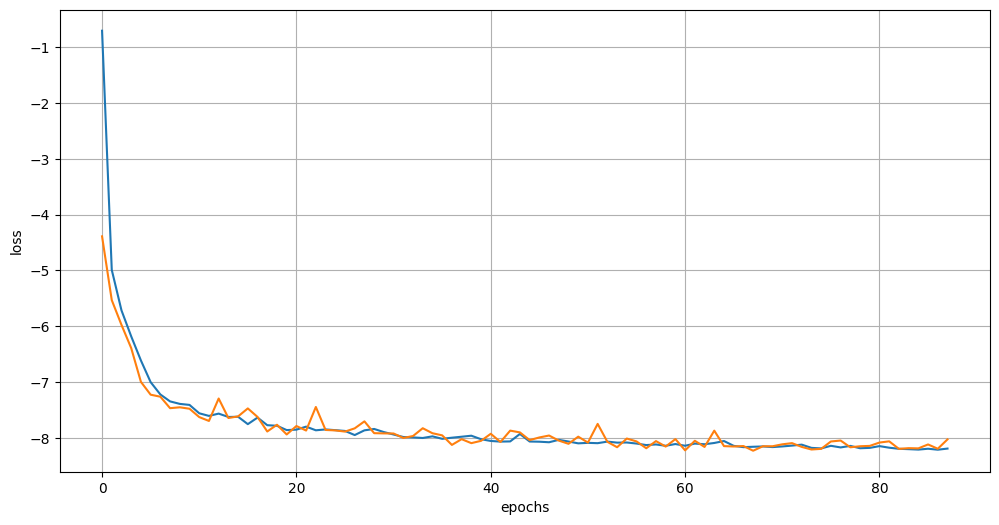

In [19]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(-np.array(inference._summary["training_log_probs"]))
ax.plot(-np.array(inference._summary["validation_log_probs"]))

ax.set(xlabel="epochs", ylabel="loss")
ax.grid(True)

In [20]:
potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, 
    prior, 
    obs_pred
)

posterior = MCMCPosterior(
    potential_fn, 
    proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=100, 
    device=device,
    # device="cpu",
    # num_workers=1,
    num_workers=128,
)

In [21]:
posterior_samples = posterior.sample(
    # (int(16384),), 
    (int(1e4),), 
    x=obs_pred, 
    show_progress_bars=True,
    method="slice_np_vectorized",
    # method="slice_np",
    # method="slice",
    # method="hmc",
    # method="nuts",
    # num_chains=20
    # num_chains=512,
    num_chains=128,
    # num_chains=1,
) 
posterior_samples = posterior_samples.cpu().numpy()
print(posterior_samples.shape)

Generating 128 MCMC inits with 128
                         workers.:   0%|          | 0/128 [00:00<?, ?it/s]

/global/u2/a/athomsen/add_on/sbi/sbi/samplers/mcmc/slice_numpy.py:393: UserWarning: Parallelization of vectorized slice sampling not implement, running
                serially.
  warn(


Running vectorized MCMC with 128 chains:   0%|          | 0/228096 [00:00<?, ?it/s]

(10000, 5)


In [22]:
label = f"{n_steps}_sbi_nle"

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

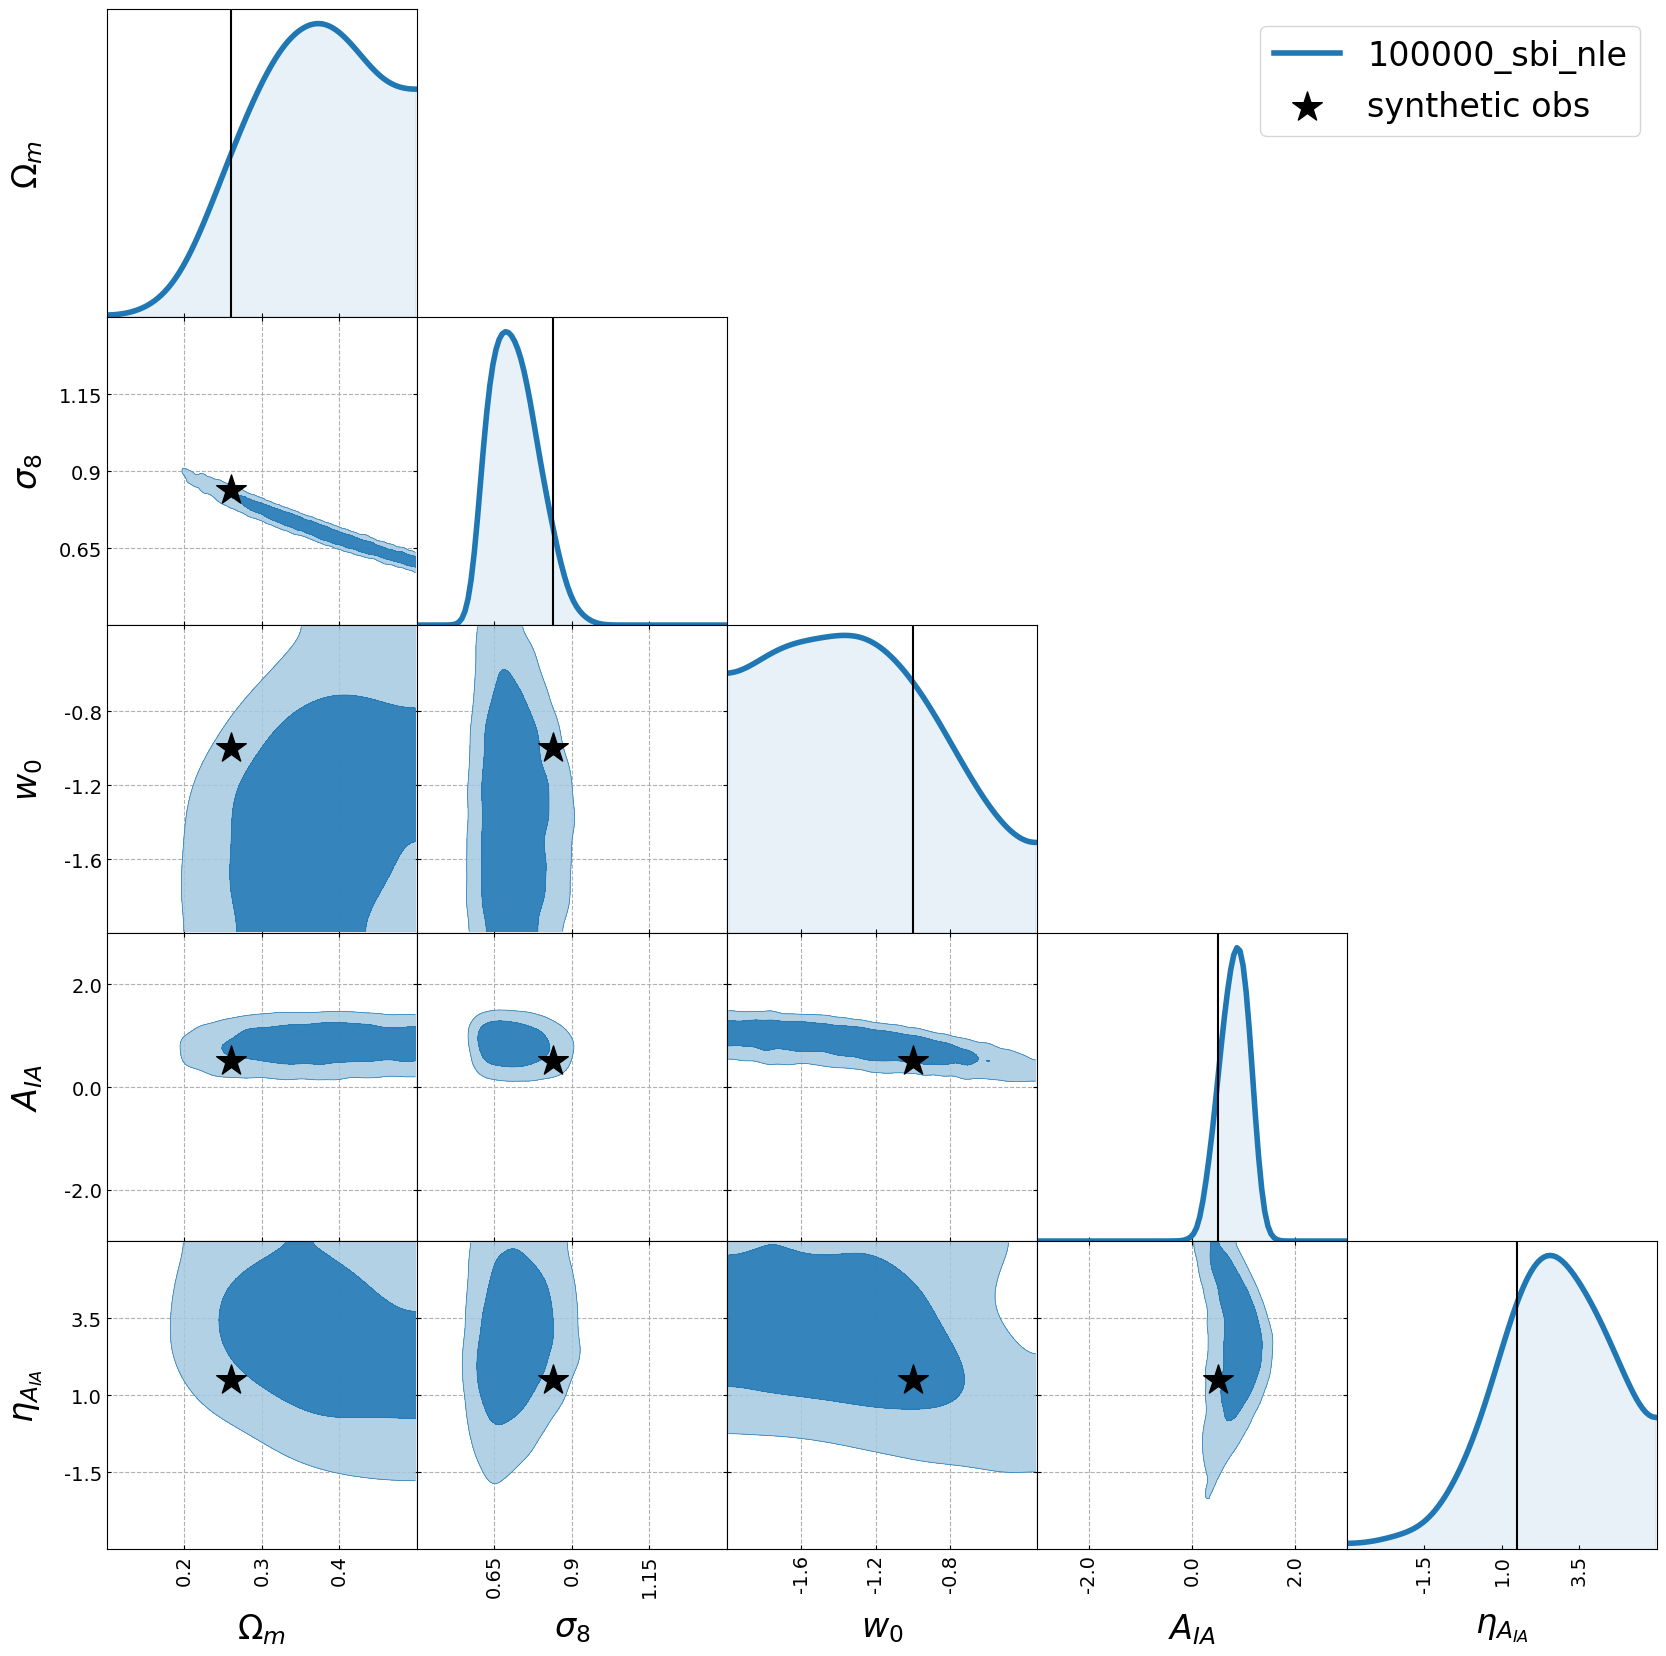

In [23]:
plotting.plot_chains(
    posterior_samples, 
    params, 
    conf=conf,
    out_dir=out_dir, 
    labels=label,
)

In [ ]:
posterior = inference.build_posterior(
    density_estimator,
)
print(posterior)

In [ ]:
posterior_samples = posterior.sample(
    (int(100),), 
    x=obs_pred, 
    show_progress_bars=True,
    # method="clice_np_vectorized",
    # device="cuda",
) 
posterior_samples = posterior_samples.cpu().numpy()

In [ ]:
plotting.plot_chains(
    posterior_samples, 
    params, 
    conf=conf,
    out_dir=out_dir, 
    labels=label,
)

# old

In [ ]:
?density_estimator.log_prob

In [ ]:
def log_likelihood(X): 
    
    X = torch.tensor(X, dtype=torch.float32, device="cpu")
    # print(X.shape)
    
    # evaluate the normal distribution
    log_prob = density_estimator.log_prob(X, context=obs_pred.unsqueeze(0)).cpu().numpy()
    
    
    
    # # enforce the prior
    # log_prob = prior.log_posterior(X, log_prob, params=params, conf=conf)

    return log_prob

In [ ]:
obs_pred.unsqueeze(0).shape

In [ ]:
params

In [ ]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
)

### plot